# DATA ANALYSIS

## Cell 1: Imports

In [31]:
import numpy as np
import scipy.sparse as sp
from collections import defaultdict
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import psutil
import time
import os


## Cell 2: Read Interaction File

In [32]:
def read_interactions(path):
    user2idx = {}
    item2idx = {}
    idx2user = []
    idx2item = []
    rows = []
    cols = []
    data = []
    user_items = defaultdict(set)

    with open(path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            user_id = parts[0]
            item_ids = parts[1:]

            if user_id not in user2idx:
                user2idx[user_id] = len(idx2user)
                idx2user.append(user_id)

            u = user2idx[user_id]

            for item_id in item_ids:
                if item_id not in item2idx:
                    item2idx[item_id] = len(idx2item)
                    idx2item.append(item_id)

                i = item2idx[item_id]

                rows.append(u)
                cols.append(i)
                data.append(1)
                user_items[u].add(i)

    interaction_matrix = sp.coo_matrix(
        (data, (rows, cols)), shape=(len(idx2user), len(idx2item))
    ).tocsr()

    return interaction_matrix, idx2user, idx2item, user_items


## Cell 3: Load Dataset

In [33]:
data_path = "/Users/hemanthsai/Downloads/train-1.txt"

interaction_matrix, idx2user, idx2item, user_items = read_interactions(data_path)

print("Interaction matrix shape:", interaction_matrix.shape)
print("Number of users:", len(idx2user))
print("Number of items:", len(idx2item))
print("Total interactions:", interaction_matrix.nnz)


Interaction matrix shape: (31668, 38048)
Number of users: 31668
Number of items: 38048
Total interactions: 1237259


## Cell 4: Analyse Dataset

In [36]:
def analyze_dataset(interaction_matrix, idx2user, idx2item, user_items):
    num_users, num_items = interaction_matrix.shape
    num_interactions = interaction_matrix.nnz
    density = num_interactions / (num_users * num_items)
    sparsity = 1 - density

    interactions_per_user = np.array([len(user_items[u]) for u in range(num_users)])
    item_popularity = np.array(interaction_matrix.sum(axis=0)).ravel()

    stats = {
        "num_users": num_users,
        "num_items": num_items,
        "num_interactions": num_interactions,
        "density": density,
        "sparsity": sparsity,
        "interactions_per_user": interactions_per_user,
        "item_popularity": item_popularity,
    }
    return stats


In [37]:
def print_dataset_stats(stats):
    num_users      = stats["num_users"]
    num_items      = stats["num_items"]
    interactions   = stats["num_interactions"]
    density        = stats["density"]
    sparsity       = stats["sparsity"] * 100
    users_arr      = stats["interactions_per_user"]
    items_arr      = stats["item_popularity"]

    # Only consider users/items with >=1 interaction
    nz_users = users_arr[users_arr > 0]
    nz_items = items_arr[items_arr > 0]

    print("\n" + "="*60)
    print("                  DATASET SUMMARY REPORT")
    print("="*60)

    print(f"{'Total Users:':30s} {num_users:10,}")
    print(f"{'Total Items:':30s} {num_items:10,}")
    print(f"{'Total Interactions:':30s} {interactions:10,}")

    print("-"*60)
    print(f"{'Matrix Density:':30s} {density:.8f}")
    print(f"{'Matrix Sparsity:':30s} {sparsity:.4f}%")

    print("-"*60)
    print("User Interaction Statistics")
    print("-"*60)
    print(f"{'Users with >0 interactions:':30s} {len(nz_users):10,}")
    print(f"{'Min interactions per user:':30s} {nz_users.min():10}")
    print(f"{'Mean interactions per user:':30s} {nz_users.mean():10.2f}")
    print(f"{'Median interactions per user:':30s} {np.median(nz_users):10.2f}")
    print(f"{'Max interactions per user:':30s} {nz_users.max():10}")

    print("-"*60)
    print("Item Popularity Statistics")
    print("-"*60)
    print(f"{'Items with >0 interactions:':30s} {len(nz_items):10,}")
    print(f"{'Min interactions per item:':30s} {nz_items.min():10}")
    print(f"{'Mean interactions per item:':30s} {nz_items.mean():10.2f}")
    print(f"{'Median interactions per item:':30s} {np.median(nz_items):10.2f}")
    print(f"{'Max interactions per item:':30s} {nz_items.max():10}")

    print("="*60 + "\n")


In [38]:
stats = analyze_dataset(interaction_matrix, idx2user, idx2item, user_items)
print_dataset_stats(stats)



                  DATASET SUMMARY REPORT
Total Users:                       31,668
Total Items:                       38,048
Total Interactions:             1,237,259
------------------------------------------------------------
Matrix Density:                0.00102685
Matrix Sparsity:               99.8973%
------------------------------------------------------------
User Interaction Statistics
------------------------------------------------------------
Users with >0 interactions:        31,668
Min interactions per user:             16
Mean interactions per user:         39.07
Median interactions per user:       25.00
Max interactions per user:           1848
------------------------------------------------------------
Item Popularity Statistics
------------------------------------------------------------
Items with >0 interactions:        38,048
Min interactions per item:              1
Mean interactions per item:         32.52
Median interactions per item:       17.00
Max interact

## Cell 7: Dataset Plotting

In [25]:
def plot_dataset(stats):
    users = stats["interactions_per_user"]
    items = stats["item_popularity"]

    # User histogram
    plt.hist(users[users > 0], bins=50)
    plt.title("User Interaction Count Distribution")
    plt.xlabel("Interactions")
    plt.ylabel("Users")
    plt.grid(True)
    plt.show()

    # Item histogram
    plt.hist(items[items > 0], bins=50)
    plt.title("Item Popularity Distribution")
    plt.xlabel("Interactions")
    plt.ylabel("Items")
    plt.grid(True)
    plt.show()

    # Log-scale versions
    plt.hist(users[users > 0], bins=50, log=True)
    plt.title("User Interaction Distribution (Log Scale)")
    plt.show()

    plt.hist(items[items > 0], bins=50, log=True)
    plt.title("Item Popularity Distribution (Log Scale)")
    plt.show()

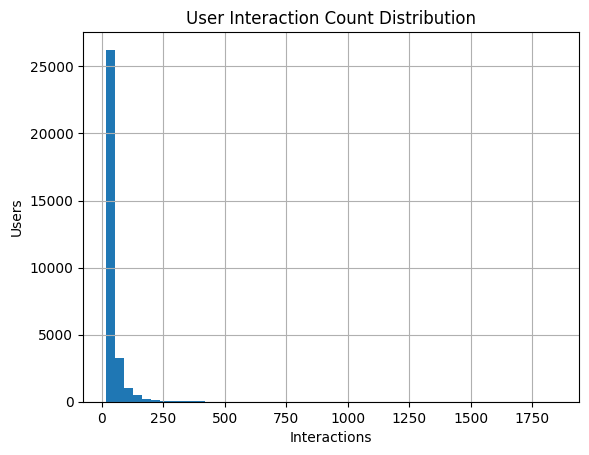

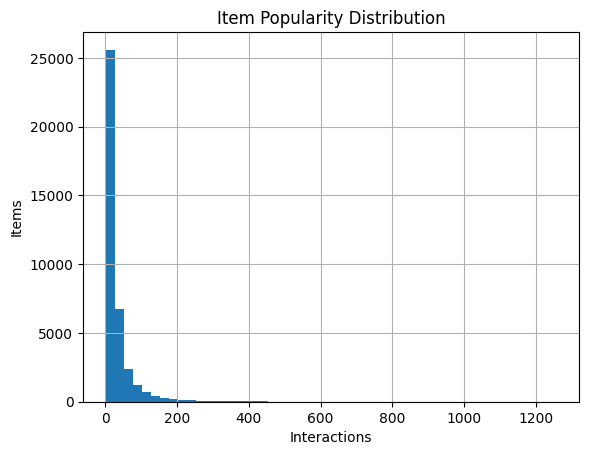

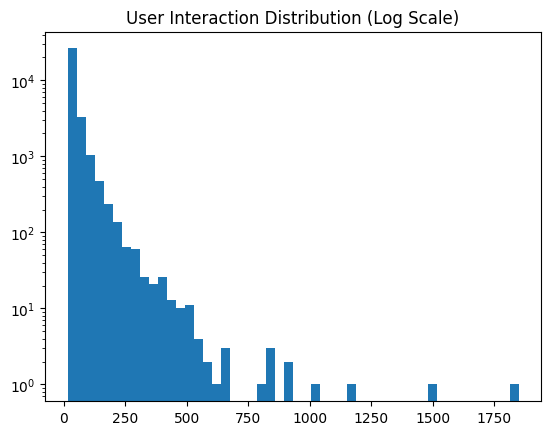

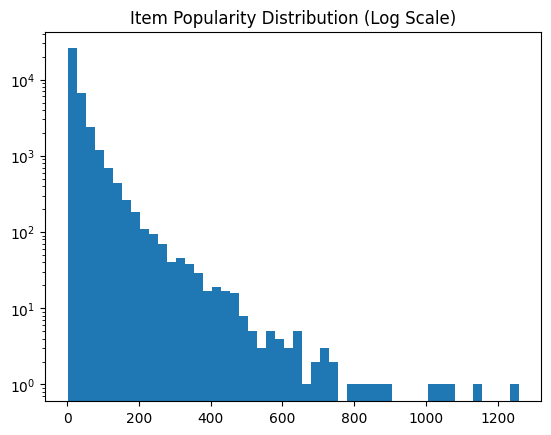

In [26]:
plot_dataset(stats)

## Cell 9: HeatMap

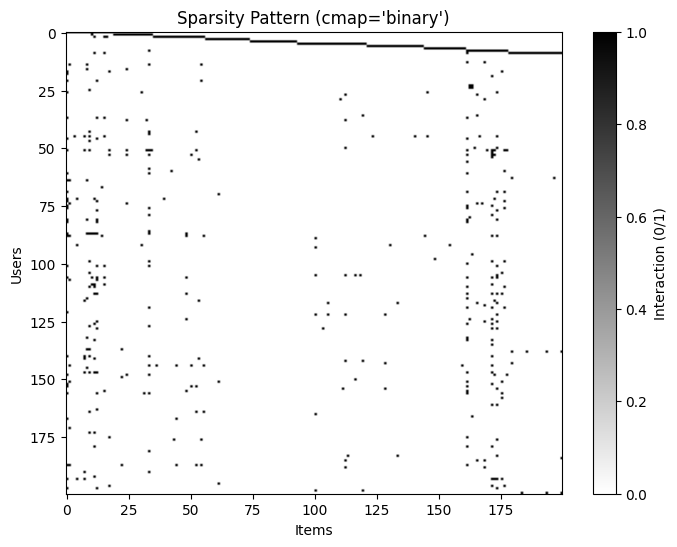

In [45]:
def plot_sparsity(interaction_matrix, max_users=200, max_items=200, cmap="inferno"):
    u = min(max_users, interaction_matrix.shape[0])
    i = min(max_items, interaction_matrix.shape[1])

    sub = interaction_matrix[:u, :i].toarray()

    plt.figure(figsize=(8, 6))
    plt.imshow(sub > 0, aspect="auto", cmap=cmap)
    plt.title(f"Sparsity Pattern (cmap='{cmap}')")
    plt.xlabel("Items")
    plt.ylabel("Users")
    plt.colorbar(label="Interaction (0/1)")
    plt.show()


plot_sparsity(interaction_matrix, cmap="binary")